In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed (42)

In [2]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Example data
X = np.array([[1], [2], [3], [4], [5]])   # independent variable
y = np.array([2, 4, 5, 4, 5])             # dependent variable

# Create and fit the model
model = LinearRegression()
model.fit(X, y)
sd_y = np.std(y, ddof=1)
# Print slope and intercept
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)
print("sd of y:", sd_y)
# Predict a new value
new_value = model.predict([[9]])
print("Prediction for x=9:", new_value)


Slope: [0.6]
Intercept: 2.2
sd of y: 1.224744871391589
Prediction for x=9: [7.6]


In [3]:
import numpy as np
import pandas as pd
np.random.seed (42)


n_rows = 120 

true_intercept = 10.0 
true_slope = 2.5
true_noise_sd = 8.0

# x = studietimmar, slumpade mellan 0 ,20
hours = np.random.uniform(0, 20, size=n_rows)

noise = np.random.normal(0, true_noise_sd, size = n_rows)

# y = sann linje + brus 
# y = 10 + 2.5 x + brus

score = true_intercept + true_slope + hours + noise

df = pd.DataFrame({
    "study_hours": hours,
    "exam_score": score 
})

df.head()






,study_hours,exam_score
0,7.490802,14.374378
1,19.014286,28.892989
2,14.639879,24.003014
3,11.973170,12.765050
4,3.120373,17.989335


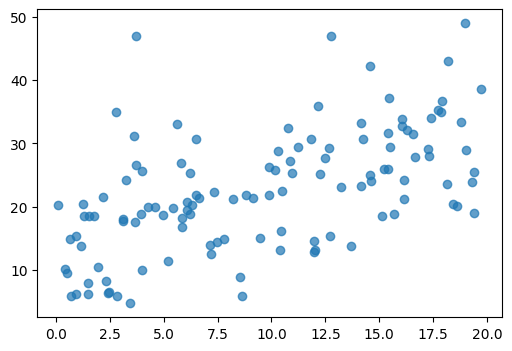

In [4]:
plt.figure(figsize=(6, 4))
plt. scatter(df["study_hours"], df["exam_score"], alpha = 0.7)

plt.show()

$$ \widehat{Y} = \hat{a} +\hat{b}  X $$

$$
\hat{\beta} = 
\begin {bmatrix}\hat{a}\\ \hat{b} \end {bmatrix}
= (X^\top X) X^{-1} X^ \top y
$$

In [5]:
x_values = df["study_hours"].values
y_values = df["exam_score"].values

# bygg upp designmatrisen : [1, x]

ones_colum = np.ones_like(x_values)
design_matrix = np.column_stack([ones_colum, x_values])

transposed_design = design_matrix.T
gram_matrix = transposed_design @ design_matrix
design_response = transposed_design @ y_values

beta_hat_vector = np.linalg.inv(gram_matrix) @design_response 

intercept_hat = float (beta_hat_vector[0])
slope_hat = float (beta_hat_vector[1])

intercept_hat, slope_hat

(13.903382739651924, 0.9054380947183421)

In [6]:
y_hat_values = intercept_hat + slope_hat * x_values
residual_values = y_values - y_hat_values

y_hat_values[:5], residual_values[:5]

(array([20.68584057, 31.11964174, 27.15888674, 24.74434669, 16.72868715]),
 array([ -6.31146295,  -2.22665279,  -3.15587313, -11.97929659,
          1.26064787]))

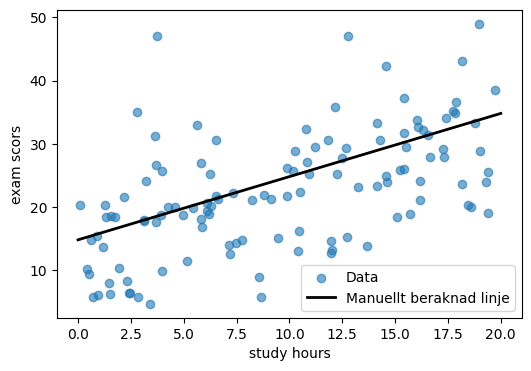

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter (x_values, y_values, alpha = 0.6, label= "Data")
grid_x = np.linspace(0,20,200)
grid_y_manual = intercept_hat + slope_hat + grid_x
plt.plot(grid_x, grid_y_manual, color = "black", linewidth=2 , label = "Manuellt beraknad linje")

plt.legend()
plt.xlabel("study hours")
plt.ylabel("exam scors")




plt.show()

Skattad skarning (a)=  13.90
Skattad lutning (6)=  0.91 point per hourse
R^2 (forklarad andel)=  1.000


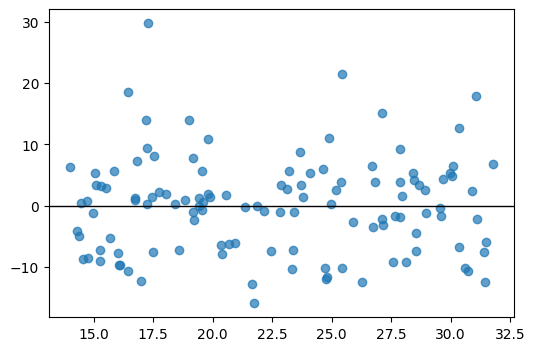

In [8]:
total_sum_of_squares = np.sum ((y_values - y_values.mean())**2)
residual_sum_of_squares = np.sum(residual_values)

r_squared = 1 - residual_sum_of_squares / total_sum_of_squares

print(f"Skattad skarning (a)= {intercept_hat: .2f}")
print(f"Skattad lutning (6)= {slope_hat: .2f} point per hourse")
print(f"R^2 (forklarad andel)= {r_squared: .3f}")

plt.figure(figsize=(6, 4))
plt. scatter(y_hat_values, residual_values, alpha = 0.7)
plt.axhline (0, color = "black", linewidth=1)
plt.show()


In [9]:
def calculate_score(hours_query):
    y_hat = intercept_hat + slope_hat * hours_query
    return y_hat

print(f"prognos vid 3 timmar {calculate_score(3):.1f}")
print(f"prognos vid 5 timmar {calculate_score(5):.1f}")
print(f"prognos vid 8 timmar {calculate_score(8):.1f}")
print(f"prognos vid 12 timmar {calculate_score (12):.1f}")

prognos vid 3 timmar 16.6
prognos vid 5 timmar 18.4
prognos vid 8 timmar 21.1
prognos vid 12 timmar 24.8


In [10]:
from sklearn.linear_model import LinearRegression

x_2d = df[["study_hours"]].values
y_1d = df[["exam_score"]].values

linreg = LinearRegression()
linreg.fit(x_2d, y_1d)

sk_intercept = float(linreg.intercept_)
sk_slope = float(linreg.coef_[0])
sk_r2 = float (linreg.score(x_2d, y_1d))
sk_pred_12 = float(linreg.predict(np.array([[12.0]]))[0])

print(f"""
    sklearn: 
    intercept = {sk_intercept:.2f}
    slope = {sk_slope:.2f}
    R^2 = {sk_r2:.3f}
    prognos vid 12h = {sk_pred_12 : .1f}
        
""")


    sklearn: 
    intercept = 13.90
    slope = 0.91
    R^2 = 0.320
    prognos vid 12h =  24.8




C:\Users\Banin\AppData\Local\Temp\ipykernel_14020\2208443388.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sk_intercept = float(linreg.intercept_)
C:\Users\Banin\AppData\Local\Temp\ipykernel_14020\2208443388.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sk_slope = float(linreg.coef_[0])
C:\Users\Banin\AppData\Local\Temp\ipykernel_14020\2208443388.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sk_pred_12 = float(linreg.predict(np.array([[12.0]]))[

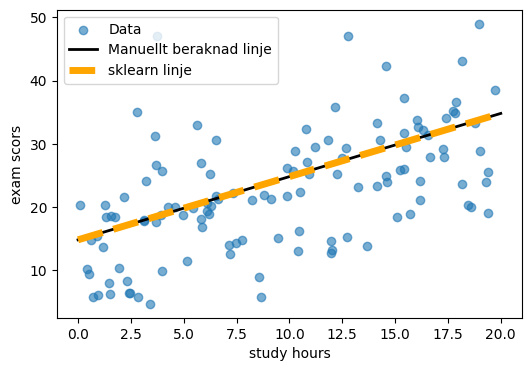

In [11]:
plt.figure(figsize=(6, 4))
plt.scatter (x_values, y_values, alpha = 0.6, label= "Data", zorder=1)
grid_x = np.linspace(0,20,200)
grid_y_manual = intercept_hat + slope_hat + grid_x
grid_y_sklearn = sk_intercept + sk_slope + grid_x

plt.plot(grid_x, grid_y_manual, color = "black", linewidth=2 , label = "Manuellt beraknad linje")
plt.plot(grid_x, grid_y_sklearn, color = "orange", linestyle= "--" ,linewidth=5, label = "sklearn linje", zorder = 3)

plt.legend()
plt.xlabel("study hours")
plt.ylabel("exam scors")




plt.show()